In [3]:
# -*- coding: utf-8 -*-
"""
PlantVillage Split‑Edge PoC – Full FKP Framework + Baselines & Ablations
-----------------------------------------------------------------------
Compares FKP (RRP) with linear probe, PCA, TASC, KD, quantisation, pruning.
Runs ablations over p, m, α/β, and number of layers.
"""

import os, time, gc, logging, re, copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.prune import global_unstructured, L1Unstructured, remove
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset
from torchvision.datasets import ImageFolder
from transformers import ViTForImageClassification, ViTImageProcessor
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt

In [4]:
# ------------------------------
# 0. Configuration
# ------------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

DATA_PATH = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"   # Adjust if needed
P_DEFAULT = 64
CALIB_SIZE = 2000
TEST_SIZE = 3000

# Certificate parameters
DELTA = 0.01
ALPHA_RIDGE_DEFAULT = 1.0
BETA_RIDGE_DEFAULT = 1.0
PCLS_VAL_SPLIT = 0.2



In [5]:
# ------------------------------
# 1. Load model and processor
# ------------------------------
logger.info("Loading ViT-B/16 model...")
model = ViTForImageClassification.from_pretrained(
    "DScomp380/vit-b16-plant_village",
    output_hidden_states=True,
).to(DEVICE).eval()

processor = ViTImageProcessor.from_pretrained("DScomp380/vit-b16-plant_village")
model_labels = [model.config.id2label[i] for i in range(len(model.config.id2label))]
NUM_CLASSES = len(model_labels)
logger.info(f"Model has {NUM_CLASSES} classes")



2026-06-04 03:24:50,773 - INFO - Loading ViT-B/16 model...
2026-06-04 03:24:51,074 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-04 03:24:51,076 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-06-04 03:24:51,086 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DScomp380/vit-b16-plant_village/81b09d25f1354d32ef00095e219cace497add20b/config.json "HTTP/1.1 200 OK"
2026-06-04 03:24:51,096 - INFO - HTTP Request: GET https://huggingface.co/api/resolve-cache/models/DScomp380/vit-b16-plant_village/81b09d25f1354d32ef00095e219cace497add20b/config.json "HTTP/1.1 200 OK"


config.json: 0.00B [00:00, ?B/s]

2026-06-04 03:24:51,326 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
2026-06-04 03:24:51,535 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-04 03:24:51,544 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DScomp380/vit-b16-plant_village/81b09d25f1354d32ef00095e219cace497add20b/config.json "HTTP/1.1 200 OK"
2026-06-04 03:24:51,752 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-06-04 03:24:51,981 - INFO - HTTP Request: GET https://huggingface.co/api/models/DScomp380/vit-b16-plant_village/xet-read-token/81b09d25f1354d32ef00095e219cace497add20b "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

2026-06-04 03:25:00,984 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-06-04 03:25:01,184 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-04 03:25:01,192 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DScomp380/vit-b16-plant_village/81b09d25f1354d32ef00095e219cace497add20b/preprocessor_config.json "HTTP/1.1 200 OK"
2026-06-04 03:25:01,202 - INFO - HTTP Request: GET https://huggingface.co/api/resolve-cache/models/DScomp380/vit-b16-plant_village/81b09d25f1354d32ef00095e219cace497add20b/preprocessor_config.json "HTTP/1.1 200 OK"


preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

2026-06-04 03:25:01,218 - INFO - Model has 39 classes


In [6]:
# ------------------------------
# 2. Custom Dataset 
# ------------------------------
def normalise_class_name(name):
    name = re.sub(r'\(.*?\)', '', name)
    name = name.replace(' ', '_')
    name = re.sub(r'_+', '_', name)
    return name.strip('_')

class PlantVillageDataset(Dataset):
    def __init__(self, root_dir, processor, model_labels):
        self.image_folder = ImageFolder(root_dir)
        self.processor = processor
        dataset_names = self.image_folder.classes
        model_names_clean = [normalise_class_name(n) for n in model_labels]
        self.label_map = {}
        for ds_idx, ds_name in enumerate(dataset_names):
            clean_ds = normalise_class_name(ds_name)
            if clean_ds in model_names_clean:
                self.label_map[ds_idx] = model_names_clean.index(clean_ds)
            else:
                self.label_map[ds_idx] = -1

    def __len__(self):
        return len(self.image_folder)

    def __getitem__(self, idx):
        img_path, ds_label = self.image_folder.samples[idx]
        img = Image.open(img_path).convert("RGB")
        inputs = self.processor(images=img, return_tensors="pt")
        model_label = self.label_map[ds_label]
        return inputs["pixel_values"].squeeze(0), model_label

full_dataset = PlantVillageDataset(DATA_PATH, processor, model_labels)
logger.info(f"Dataset loaded: {len(full_dataset)} images")

# Filter valid samples
valid_indices = [i for i in range(len(full_dataset))
                 if full_dataset.label_map[full_dataset.image_folder.samples[i][1]] != -1]
logger.info(f"Valid mapped samples: {len(valid_indices)}")

np.random.shuffle(valid_indices)
calib_idx = valid_indices[:CALIB_SIZE]
test_idx = valid_indices[CALIB_SIZE:CALIB_SIZE + TEST_SIZE]

calib_dataset = Subset(full_dataset, calib_idx)
test_dataset = Subset(full_dataset, test_idx)

calib_loader = DataLoader(calib_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)



2026-06-04 03:25:47,356 - INFO - Dataset loaded: 54305 images
2026-06-04 03:25:47,363 - INFO - Valid mapped samples: 54305


In [7]:
# ------------------------------
# 3. Feature extraction (with per‑layer option)
# ------------------------------
def extract_features_and_logits(dataloader, return_per_layer=False):
    """Returns concatenated features, logits, labels. If return_per_layer, also returns list of per-layer features."""
    features_list = []
    logits_list = []
    labels_list = []
    if return_per_layer:
        per_layer_list = []  # list of lists (per layer)

    with torch.no_grad():
        for imgs, labels in tqdm(dataloader, desc="Extracting"):
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            logits_list.append(outputs.logits.cpu().numpy())
            hidden = outputs.hidden_states[1:]   # skip patch embeddings, 12 layers
            batch_cls = [h[:, 0, :].cpu().numpy() for h in hidden]  # each (batch, 768)
            features = np.concatenate(batch_cls, axis=1)             # (batch, 9216)
            features_list.append(features)
            labels_list.extend(labels.tolist())
            if return_per_layer:
                if not per_layer_list:
                    per_layer_list = [[] for _ in range(len(batch_cls))]
                for i, cls in enumerate(batch_cls):
                    per_layer_list[i].append(cls)

    features = np.concatenate(features_list, axis=0)
    logits = np.concatenate(logits_list, axis=0)
    labels = np.array(labels_list)

    if return_per_layer:
        per_layer_features = [np.concatenate(per_layer_list[i], axis=0) for i in range(len(per_layer_list))]
        return features, logits, labels, per_layer_features
    return features, logits, labels

# Extract calibration & test with per-layer for layer ablation
E_calib, H_calib, Y_calib, E_calib_per_layer = extract_features_and_logits(calib_loader, return_per_layer=True)
E_test, H_test, Y_test, E_test_per_layer = extract_features_and_logits(test_loader, return_per_layer=True)



Extracting:   0%|          | 0/63 [00:00<?, ?it/s]

Extracting:   0%|          | 0/94 [00:00<?, ?it/s]

In [8]:
# ------------------------------
# 4. FKP core functions (PCLS, RRP, Certificate) – unchanged from original
# ------------------------------
def compute_pcls(E, H, alpha=ALPHA_RIDGE_DEFAULT, val_split=PCLS_VAL_SPLIT, n_bootstrap=200):
    E_train, E_val, H_train, H_val = train_test_split(E, H, test_size=val_split, random_state=SEED)
    m_train = E_train.shape[0]
    mean_E = E_train.mean(0, keepdims=True)
    mean_H = H_train.mean(0, keepdims=True)
    Ec_train = E_train - mean_E
    Hc_train = H_train - mean_H
    W = np.linalg.solve(Ec_train.T @ Ec_train + alpha * np.eye(Ec_train.shape[1]), Ec_train.T @ Hc_train)
    Ec_val = E_val - mean_E
    H_pred = Ec_val @ W + mean_H
    ss_res = np.sum((H_val - H_pred)**2)
    ss_tot = np.sum((H_val - mean_H)**2)
    pcls = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0
    # Bootstrap CI
    pcls_boot = []
    rng = np.random.RandomState(SEED)
    for _ in range(n_bootstrap):
        idx = rng.choice(len(E_val), len(E_val), replace=True)
        ss_res_b = np.sum((H_val[idx] - H_pred[idx])**2)
        ss_tot_b = np.sum((H_val[idx] - mean_H)**2)
        pcls_b = 1 - ss_res_b / ss_tot_b if ss_tot_b > 0 else 1.0
        pcls_boot.append(pcls_b)
    ci_low = np.percentile(pcls_boot, 2.5)
    ci_high = np.percentile(pcls_boot, 97.5)
    cov = Ec_train.T @ Ec_train / m_train
    cond = np.linalg.cond(cov)
    return pcls, (ci_low, ci_high), cond

def rrp_fit(E, H, p, alpha=ALPHA_RIDGE_DEFAULT, beta=BETA_RIDGE_DEFAULT):
    mean = E.mean(axis=0, keepdims=True).astype(np.float32)
    Ec = E.astype(np.float32) - mean
    Hc = H.astype(np.float32) - H.mean(axis=0, keepdims=True)
    W_ridge = np.linalg.solve(Ec.T @ Ec + alpha * np.eye(Ec.shape[1]), Ec.T @ Hc).astype(np.float32)
    Uw, sw, _ = np.linalg.svd(W_ridge, full_matrices=False)
    U = Uw[:, :p].astype(np.float32)
    sigma_p = sw[p-1] if len(sw) >= p else 0.0
    sigma_p1 = sw[p] if len(sw) > p else 0.0
    Z = Ec @ U
    ridge = Ridge(alpha=beta, fit_intercept=True)
    ridge.fit(Z, H.astype(np.float32))
    W = ridge.coef_.T.astype(np.float32)
    b = ridge.intercept_.astype(np.float32)
    residual = np.linalg.norm(Hc - Ec @ W_ridge, 'fro')**2 / Ec.shape[0]
    tail_sq = np.sum(sw[p:]**2) if len(sw) > p else 0.0
    return U, mean, W, b, {
        "residual": residual, "tail_sq": tail_sq, "sw": sw,
        "sigma_p": sigma_p, "sigma_p1": sigma_p1,
        "W_ridge_norm": np.linalg.norm(W_ridge, 'fro'),
        "E_cov": Ec.T @ Ec / Ec.shape[0]
    }

def compute_certificate(E, H, U, W, b, sw, sigma_p, sigma_p1, W_ridge_norm,
                        alpha=ALPHA_RIDGE_DEFAULT, delta=DELTA):
    m, D = E.shape
    mean = E.mean(0, keepdims=True)
    Ec = E - mean
    Hc = H - H.mean(0, keepdims=True)
    W_ridge_full = np.linalg.solve(Ec.T @ Ec + alpha * np.eye(D), Ec.T @ Hc)
    residual_full = np.linalg.norm(Hc - Ec @ W_ridge_full, 'fro')**2 / m
    gamma = 2 * alpha * W_ridge_norm**2 / m
    conf_term = np.sqrt(2 * np.log(2/delta) / m) * (residual_full + gamma)
    eps_stab = residual_full + gamma + conf_term
    _, S, _ = np.linalg.svd(Ec, full_matrices=False)
    sigma_E = S[0] / np.sqrt(m)
    log_term = np.sqrt(2 * np.log(2/delta) / m) + 2 * np.log(2/delta) / m
    R_delta = sigma_E * (1 + log_term)
    eps_proj = R_delta**2 * (sigma_p1**2)
    eps_delta = eps_stab + eps_proj
    return {
        "eps_stab": eps_stab, "R_delta": R_delta, "eps_proj": eps_proj,
        "eps_delta": eps_delta, "sigma_E": sigma_E,
        "residual_full": residual_full, "gamma": gamma
    }

def evaluate_edge(E_test, mean, U, W, b, Y_test):
    Z = (E_test.astype(np.float32) - mean) @ U
    logits = Z @ W + b
    preds = np.argmax(logits, axis=1)
    return accuracy_score(Y_test, preds)



In [9]:
# ------------------------------
# 5. Baseline Methods
# ------------------------------

# 5.1 Linear probe on last layer only (using labels)
def linear_probe_last_layer(E_last, Y, alpha=1.0):
    """E_last: features of only the final layer. Y: integer labels."""
    # One-hot encode labels
    Y_onehot = np.eye(NUM_CLASSES)[Y]
    # Ridge regression
    ridge = Ridge(alpha=alpha, fit_intercept=True)
    ridge.fit(E_last, Y_onehot)
    W = ridge.coef_.T  # (d_last, c)
    b = ridge.intercept_
    preds = np.argmax(E_last @ W + b, axis=1)
    acc = accuracy_score(Y, preds)
    return acc, W, b

# 5.2 PCA + Linear (unsupervised PCA, supervised linear head)
def pca_linear_baseline(E_train, Y_train, E_test, Y_test, p):
    """PCA on training features, then ridge regression with labels."""
    pca = PCA(n_components=p, random_state=SEED)
    Z_train = pca.fit_transform(E_train)
    Z_test = pca.transform(E_test)
    # Ridge with one-hot labels
    Y_onehot = np.eye(NUM_CLASSES)[Y_train]
    ridge = Ridge(alpha=1.0, fit_intercept=True)
    ridge.fit(Z_train, Y_onehot)
    W = ridge.coef_.T
    b = ridge.intercept_
    preds = np.argmax(Z_test @ W + b, axis=1)
    acc = accuracy_score(Y_test, preds)
    return acc

# 5.3 TASC (whitened CCA) – supervised by teacher logits, no labels
def tasc_fit(E_train, H_train, p, alpha=1e-4):
    mean = E_train.mean(0, keepdims=True)
    Ec = E_train - mean
    Hc = H_train - H_train.mean(0, keepdims=True)
    m = Ec.shape[0]
    # Whitening
    Ue, se, _ = np.linalg.svd(Ec.T @ Ec / (m-1), full_matrices=False)
    S_w = Ue @ np.diag(1.0/np.sqrt(se + alpha))
    C = Ec.T @ Hc / (m-1)
    Cw = S_w.T @ C
    Uc, sc, _ = np.linalg.svd(Cw, full_matrices=False)
    U = S_w @ Uc[:, :p]
    Z = Ec @ U
    ridge = Ridge(alpha=1.0, fit_intercept=True)
    ridge.fit(Z, H_train)
    W = ridge.coef_.T
    b = ridge.intercept_
    return U, mean, W, b

def evaluate_tasc(E_test, mean, U, W, b, Y_test):
    Z = (E_test - mean) @ U
    logits = Z @ W + b
    preds = np.argmax(logits, axis=1)
    return accuracy_score(Y_test, preds)

# 5.4 Knowledge Distillation (linear student, logit matching)
def kd_linear_student(E_train, H_train, E_test, Y_test, p, epochs=200, lr=1e-3):
    """Train a linear model (D->p->c) with MSE loss between student logits and teacher logits."""
    # We'll use a simple two-layer network (no hidden activation? Actually a linear model from D to c, but projection p is the bottleneck. We can do D -> p -> c with linear activation (i.e., one linear layer after projection). For simplicity, just a single linear layer from D to c trained with MSE.
    # FKP uses ridge; KD uses gradient descent with MSE on logits.
    D = E_train.shape[1]
    c = H_train.shape[1]
    # Define a linear model (no hidden layer) to match teacher logits
    class LinearStudent(nn.Module):
        def __init__(self, D, c):
            super().__init__()
            self.linear = nn.Linear(D, c)
        def forward(self, x):
            return self.linear(x)

    # Prepare data
    X = torch.tensor(E_train, dtype=torch.float32).to(DEVICE)
    y = torch.tensor(H_train, dtype=torch.float32).to(DEVICE)  # teacher logits
    dataset = TensorDataset(X, y)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)

    student = LinearStudent(D, c).to(DEVICE)
    optimizer = optim.Adam(student.parameters(), lr=lr)
    criterion = nn.MSELoss()

    student.train()
    for epoch in range(epochs):
        for bx, by in loader:
            optimizer.zero_grad()
            logits = student(bx)
            loss = criterion(logits, by)
            loss.backward()
            optimizer.step()

    # Evaluate on test
    student.eval()
    with torch.no_grad():
        X_test = torch.tensor(E_test, dtype=torch.float32).to(DEVICE)
        logits_test = student(X_test).cpu().numpy()
    preds = np.argmax(logits_test, axis=1)
    acc = accuracy_score(Y_test, preds)
    return acc

# 5.5 Teacher Quantization (dynamic, int8)
def quantized_teacher_accuracy(test_loader):
    """Apply dynamic quantization to ViT and evaluate test accuracy."""
    # We need a copy of the model in CPU mode
    model_cpu = ViTForImageClassification.from_pretrained(
        "DScomp380/vit-b16-plant_village",
        output_hidden_states=True,
    ).cpu().eval()
    # Specify which layers to quantize (e.g., all nn.Linear)
    model_q = torch.quantization.quantize_dynamic(
        model_cpu, {nn.Linear}, dtype=torch.qint8
    )
    # Evaluate
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc="Quant eval"):
            imgs = imgs.to('cpu')  # quantized model runs on CPU
            outputs = model_q(imgs)
            preds = outputs.logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += len(labels)
    return correct / total

# 5.6 Teacher Pruning (global unstructured)
def pruned_teacher_accuracy(test_loader, amount=0.5):
    """Globally prune 50% of model weights (smallest magnitude) and evaluate."""
    model_prune = ViTForImageClassification.from_pretrained(
        "DScomp380/vit-b16-plant_village",
        output_hidden_states=True,
    ).to(DEVICE).eval()
    parameters_to_prune = []
    for name, module in model_prune.named_modules():
        if isinstance(module, nn.Linear):
            parameters_to_prune.append((module, 'weight'))
    global_unstructured(
        parameters_to_prune,
        pruning_method=L1Unstructured,
        amount=amount,
    )
    # Make pruning permanent
    for module, _ in parameters_to_prune:
        remove(module, 'weight')
    # Evaluate
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc="Prune eval"):
            imgs = imgs.to(DEVICE)
            outputs = model_prune(imgs)
            preds = outputs.logits.argmax(dim=1).cpu()
            correct += (preds == labels).sum().item()
            total += len(labels)
    return correct / total

In [10]:

# ------------------------------
# 6. Ablation Functions
# ------------------------------
def ablation_p_values(p_list, E_calib, H_calib, Y_calib, E_test, Y_test):
    results = []
    for p in p_list:
        U, mean, W, b, info = rrp_fit(E_calib, H_calib, p)
        acc = evaluate_edge(E_test, mean, U, W, b, Y_test)
        results.append(acc)
    return results

def ablation_calibration_sizes(sizes, full_dataset, calib_indices_pool, test_idx, p_default):
    accs = []
    for size in sizes:
        # Random sample from the pool (which is already shuffled valid indices)
        calib_idx = calib_indices_pool[:size]
        calib_dataset = Subset(full_dataset, calib_idx)
        calib_loader = DataLoader(calib_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
        E_calib, H_calib, Y_calib = extract_features_and_logits(calib_loader)
        U, mean, W, b, _ = rrp_fit(E_calib, H_calib, p_default)
        # Evaluate on the fixed test set (E_test, Y_test already loaded)
        acc = evaluate_edge(E_test, mean, U, W, b, Y_test)
        accs.append(acc)
    return accs

def ablation_alpha_beta(alpha_vals, beta_vals, E_calib, H_calib, Y_calib, E_test, Y_test, p_default):
    results = np.zeros((len(alpha_vals), len(beta_vals)))
    for i, a in enumerate(alpha_vals):
        for j, b in enumerate(beta_vals):
            U, mean, W, bb, _ = rrp_fit(E_calib, H_calib, p_default, alpha=a, beta=b)
            acc = evaluate_edge(E_test, mean, U, W, bb, Y_test)
            results[i, j] = acc
    return results

def ablation_layers(num_layers_list, E_calib_per_layer, E_test_per_layer, H_calib, Y_calib, Y_test, p_default):
    """Use only the last k layers (k from num_layers_list)."""
    accs = []
    for k in num_layers_list:
        # Concatenate features from the last k layers
        # Layers are ordered from 0 (first block) to 11 (last block)
        # We want the last k: indices 12-k to 11
        start_layer = 12 - k
        E_calib_k = np.concatenate(E_calib_per_layer[start_layer:], axis=1)
        E_test_k = np.concatenate(E_test_per_layer[start_layer:], axis=1)
        U, mean, W, b, _ = rrp_fit(E_calib_k, H_calib, p_default)
        acc = evaluate_edge(E_test_k, mean, U, W, b, Y_test)
        accs.append(acc)
    return accs



In [11]:
# ------------------------------
# 7. Run Baselines 
# ------------------------------
logger.info("=== Baselines ===")
results = {}

# Teacher original accuracy
results['Teacher (full)'] = accuracy_score(Y_test, np.argmax(H_test, axis=1))

# 5.1 Linear probe on last layer
# Use last layer features: E_calib_per_layer[-1], E_test_per_layer[-1]
acc_lp, W_lp, b_lp = linear_probe_last_layer(E_calib_per_layer[-1], Y_calib)
results['Linear Probe (last)'] = acc_lp

# 5.2 PCA + Linear (p=64)
acc_pca = pca_linear_baseline(E_calib, Y_calib, E_test, Y_test, p=64)
results['PCA+Linear (p=64)'] = acc_pca

# 5.3 TASC (p=64)
U_tasc, mean_tasc, W_tasc, b_tasc = tasc_fit(E_calib, H_calib, p=64)
acc_tasc = evaluate_tasc(E_test, mean_tasc, U_tasc, W_tasc, b_tasc, Y_test)
results['TASC (p=64)'] = acc_tasc

# 5.4 Knowledge Distillation (linear student, logit matching)
# Use same p=64? KD uses full D features, no projection. We'll train a linear layer from D to c.
acc_kd = kd_linear_student(E_calib, H_calib, E_test, Y_test, p=64, epochs=200, lr=1e-3)
results['KD (linear logit)'] = acc_kd

# 5.5 Quantization
acc_quant = quantized_teacher_accuracy(test_loader)
results['Teacher int8'] = acc_quant

# 5.6 Pruning (50%)
acc_prune = pruned_teacher_accuracy(test_loader, amount=0.5)
results['Teacher pruned 50%'] = acc_prune

# FKP (RRP) with default p=64
U_fkp, mean_fkp, W_fkp, b_fkp, info_fkp = rrp_fit(E_calib, H_calib, P_DEFAULT)
acc_fkp = evaluate_edge(E_test, mean_fkp, U_fkp, W_fkp, b_fkp, Y_test)
results['FKP (RRP, p=64)'] = acc_fkp

# Print baseline table
print("\n=== Baseline Comparison ===")
print(f"{'Method':<25} {'Accuracy':<10} {'Uses Labels?':<12}")
print("-"*47)
for name, acc in results.items():
    uses_labels = "Yes" if name in ['Linear Probe (last)', 'PCA+Linear (p=64)'] else ("N/A" if "Teacher" in name else "No")
    print(f"{name:<25} {acc*100:>9.2f}% {uses_labels:>12}")
print("-"*47)


2026-06-04 03:26:56,212 - INFO - === Baselines ===
2026-06-04 03:31:47,807 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-04 03:31:47,815 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DScomp380/vit-b16-plant_village/81b09d25f1354d32ef00095e219cace497add20b/config.json "HTTP/1.1 200 OK"
2026-06-04 03:31:48,022 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-04 03:31:48,029 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DScomp380/vit-b16-plant_village/81b09d25f1354d32ef00095e219cace497add20b/config.json "HTTP/1.1 200 OK"
2026-06-04 03:31:48,235 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

/tmp/ipykernel_58/390697608.py:113: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_q = torch.quantization.quantize_dynamic(


Quant eval:   0%|          | 0/94 [00:00<?, ?it/s]

2026-06-04 03:45:33,614 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-04 03:45:33,623 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DScomp380/vit-b16-plant_village/81b09d25f1354d32ef00095e219cace497add20b/config.json "HTTP/1.1 200 OK"
2026-06-04 03:45:33,855 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-04 03:45:33,863 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DScomp380/vit-b16-plant_village/81b09d25f1354d32ef00095e219cace497add20b/config.json "HTTP/1.1 200 OK"
2026-06-04 03:45:34,064 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Prune eval:   0%|          | 0/94 [00:00<?, ?it/s]


=== Baseline Comparison ===
Method                    Accuracy   Uses Labels?
-----------------------------------------------
Teacher (full)                99.93%          N/A
Linear Probe (last)          100.00%          Yes
PCA+Linear (p=64)             99.90%          Yes
TASC (p=64)                   99.93%           No
KD (linear logit)             99.93%           No
Teacher int8                  99.93%          N/A
Teacher pruned 50%            99.50%          N/A
FKP (RRP, p=64)               99.93%           No
-----------------------------------------------


2026-06-04 03:50:34,037 - INFO - === Ablations ===


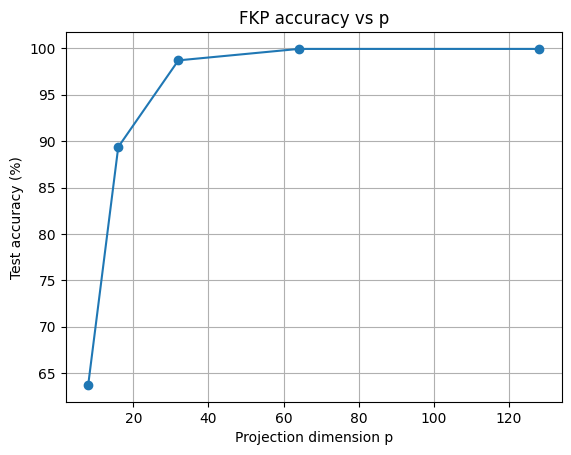

Ablation p: {8: 0.6373333333333333, 16: 0.8936666666666667, 32: 0.987, 64: 0.9993333333333333, 128: 0.9993333333333333}


Extracting:   0%|          | 0/2 [00:00<?, ?it/s]

Extracting:   0%|          | 0/4 [00:00<?, ?it/s]

Extracting:   0%|          | 0/7 [00:00<?, ?it/s]

Extracting:   0%|          | 0/16 [00:00<?, ?it/s]

Extracting:   0%|          | 0/32 [00:00<?, ?it/s]

Extracting:   0%|          | 0/63 [00:00<?, ?it/s]

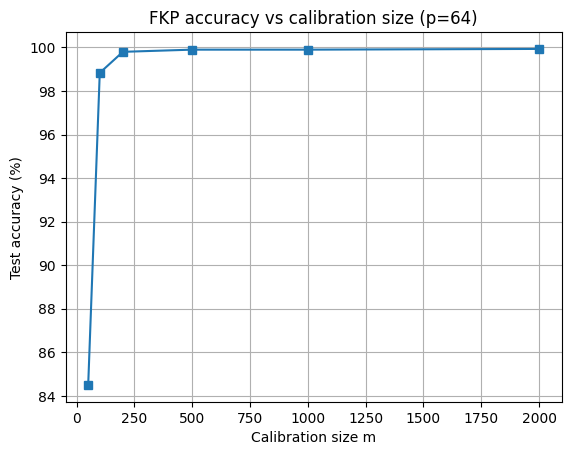

Ablation m: {50: 0.845, 100: 0.9883333333333333, 200: 0.998, 500: 0.999, 1000: 0.999, 2000: 0.9993333333333333}
Ablation α/β matrix:
α=0.01, β=0.01: 26.87%
α=0.01, β=0.10: 38.00%
α=0.01, β=1.00: 53.97%
α=0.01, β=10.00: 78.90%
α=0.10, β=0.01: 32.10%
α=0.10, β=0.10: 40.83%
α=0.10, β=1.00: 59.60%
α=0.10, β=10.00: 86.63%
α=1.00, β=0.01: 99.93%
α=1.00, β=0.10: 99.93%
α=1.00, β=1.00: 99.93%
α=1.00, β=10.00: 99.93%
α=10.00, β=0.01: 99.93%
α=10.00, β=0.10: 99.93%
α=10.00, β=1.00: 99.93%
α=10.00, β=10.00: 99.93%


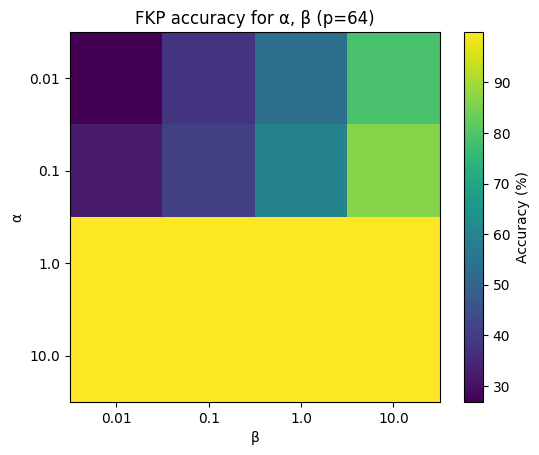

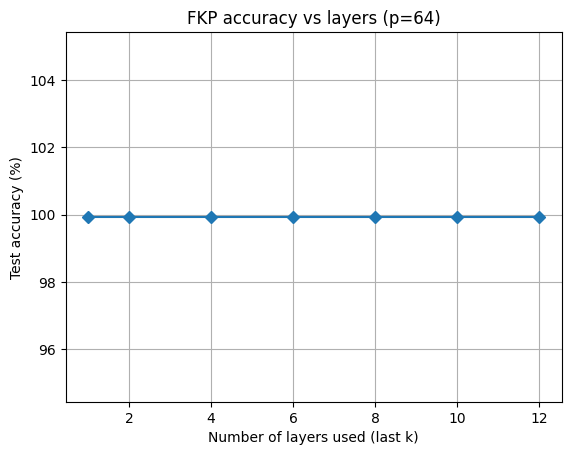

Ablation layers: {1: 0.9993333333333333, 2: 0.9993333333333333, 4: 0.9993333333333333, 6: 0.9993333333333333, 8: 0.9993333333333333, 10: 0.9993333333333333, 12: 0.9993333333333333}


In [12]:

# ------------------------------
# 8. Ablations
# ------------------------------
logger.info("=== Ablations ===")

# 8.1 Projection dimension p
p_vals = [8, 16, 32, 64, 128]
acc_p = ablation_p_values(p_vals, E_calib, H_calib, Y_calib, E_test, Y_test)
plt.figure()
plt.plot(p_vals, [acc*100 for acc in acc_p], 'o-')
plt.xlabel('Projection dimension p')
plt.ylabel('Test accuracy (%)')
plt.title('FKP accuracy vs p')
plt.grid(True)
plt.savefig('ablation_p.png', dpi=150)
plt.show()
print("Ablation p:", dict(zip(p_vals, acc_p)))

# 8.2 Calibration size m
m_vals = [50, 100, 200, 500, 1000, 2000]
# Use the already shuffled valid_indices as pool
acc_m = ablation_calibration_sizes(m_vals, full_dataset, valid_indices, test_idx, P_DEFAULT)
plt.figure()
plt.plot(m_vals, [acc*100 for acc in acc_m], 's-')
plt.xlabel('Calibration size m')
plt.ylabel('Test accuracy (%)')
plt.title('FKP accuracy vs calibration size (p=64)')
plt.grid(True)
plt.savefig('ablation_m.png', dpi=150)
plt.show()
print("Ablation m:", dict(zip(m_vals, acc_m)))

# 8.3 Ridge parameters α, β
alpha_vals = [0.01, 0.1, 1.0, 10.0]
beta_vals = [0.01, 0.1, 1.0, 10.0]
acc_ab = ablation_alpha_beta(alpha_vals, beta_vals, E_calib, H_calib, Y_calib, E_test, Y_test, P_DEFAULT)
print("Ablation α/β matrix:")
for i, a in enumerate(alpha_vals):
    for j, b in enumerate(beta_vals):
        print(f"α={a:.2f}, β={b:.2f}: {acc_ab[i,j]*100:.2f}%")
# Simple plot
plt.figure()
plt.imshow(acc_ab*100, interpolation='nearest', cmap='viridis')
plt.xticks(range(len(beta_vals)), beta_vals)
plt.yticks(range(len(alpha_vals)), alpha_vals)
plt.xlabel('β')
plt.ylabel('α')
plt.colorbar(label='Accuracy (%)')
plt.title('FKP accuracy for α, β (p=64)')
plt.savefig('ablation_alpha_beta.png', dpi=150)
plt.show()

# 8.4 Number of layers
layer_counts = [1, 2, 4, 6, 8, 10, 12]
acc_layers = ablation_layers(layer_counts, E_calib_per_layer, E_test_per_layer, H_calib, Y_calib, Y_test, P_DEFAULT)
plt.figure()
plt.plot(layer_counts, [acc*100 for acc in acc_layers], 'D-')
plt.xlabel('Number of layers used (last k)')
plt.ylabel('Test accuracy (%)')
plt.title('FKP accuracy vs layers (p=64)')
plt.grid(True)
plt.savefig('ablation_layers.png', dpi=150)
plt.show()
print("Ablation layers:", dict(zip(layer_counts, acc_layers)))



In [16]:
# Save the edge model
np.savez_compressed("rrp_edge_model.npz",
                    U=U_fkp, mean=mean_fkp, W=W_fkp, b=b_fkp,
                    classes=np.array(model_labels))
logger.info("Edge model saved to rrp_edge_model.npz")




2026-06-04 04:01:26,047 - INFO - Edge model saved to rrp_edge_model.npz


In [23]:
# -*- coding: utf-8 -*-
"""Live Split‑Edge Demo with Saved RRP Model (PlantVillage)"""

import numpy as np
import torch
from PIL import Image
from transformers import ViTForImageClassification, ViTImageProcessor
import time, logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(message)s')
logger = logging.getLogger(__name__)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------
# 1. Load the saved edge model
# -------------------------------
data = np.load("rrp_edge_model.npz")
U = data["U"]            # (9216, 64)
mean = data["mean"]      # (1, 9216)
W = data["W"]            # (64, 39)
b = data["b"]            # (39,)
class_names = ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust',
               'Apple___healthy', 'Background_without_leaves', 'Blueberry___healthy',
               'Cherry___Powdery_mildew', 'Cherry___healthy', 'Corn___Cercospora_leaf_spot Gray_leaf_spot',
               'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy',
               'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
               'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot',
               'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy',
               'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy',
               'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew',
               'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot',
               'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold',
               'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite',
               'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
               'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
logger.info("Edge model loaded: W %s, b %s", W.shape, b.shape)

# -------------------------------
# 2. Load teacher model (server)
# -------------------------------
logger.info("Loading ViT-B/16...")
model = ViTForImageClassification.from_pretrained(
    "DScomp380/vit-b16-plant_village",
    output_hidden_states=True,
).to(DEVICE).eval()
processor = ViTImageProcessor.from_pretrained("DScomp380/vit-b16-plant_village")

# -------------------------------
# 3. Choose an image (UNSEEN by edge)
# -------------------------------
# Option A: Use any file path
IMG_PATH = "/kaggle/input/datasets/yusufmurtaza01/grape-leaf-diseases/grape/images/val/pv_GRBR_image (1059).jpg"
# Option B: Pick a random test set image from the earlier loaded dataset (if still available)
# For standalone demo, we'll just use a sample from your dataset folder.
# We'll load it via PIL.
img = Image.open(IMG_PATH).convert("RGB")

# -------------------------------
# 4. Server-side: feature extraction & projection
# -------------------------------
start = time.time()
inputs = processor(images=img, return_tensors="pt")
pixel_values = inputs["pixel_values"].to(DEVICE)

with torch.no_grad():
    outputs = model(pixel_values)
    teacher_logits = outputs.logits.cpu().numpy()
    hidden = outputs.hidden_states[1:]          # skip embeddings
    cls_tokens = [h[:, 0, :].cpu().numpy() for h in hidden]
    full_features = np.concatenate(cls_tokens, axis=1)   # (1, 9216)

# RRP projection (centring + matmul)
z = (full_features.astype(np.float32) - mean) @ U   # (1, 64)
server_time = (time.time() - start) * 1000
logger.info(f"Server processing: {server_time:.2f} ms")
logger.info(f"Compressed vector z shape: {z.shape}, payload: {z.nbytes} bytes")

# -------------------------------
# 5. Simulate transmission (just pass z)
# -------------------------------
transmitted_z = z   # in reality would be sent over BLE/WiFi

# -------------------------------
# 6. Edge device: linear classifier
# -------------------------------
start = time.perf_counter()
logits = transmitted_z @ W + b      # (1, 39)
# softmax probabilities
probs = np.exp(logits - np.max(logits)) / np.sum(np.exp(logits - np.max(logits)), axis=1, keepdims=True)
edge_time = (time.perf_counter() - start) * 1e6   # µs
edge_pred = np.argmax(logits)
edge_conf = probs[0, edge_pred]

# Teacher prediction for comparison
teacher_pred = np.argmax(teacher_logits)
teacher_conf = np.max(np.exp(teacher_logits - np.max(teacher_logits)) /
                      np.sum(np.exp(teacher_logits - np.max(teacher_logits)), axis=1))

# -------------------------------
# 7. Show results
# -------------------------------
print("\n" + "="*50)
print("Split‑Edge Live Inference")
print("="*50)
print(f"Image: {IMG_PATH}")
print(f"Server time: {server_time:.2f} ms")
print(f"Payload sent: {z.size} float32 ({z.nbytes} bytes)")
print(f"Edge inference time: {edge_time:.2f} µs")
print(f"\nTeacher (ViT‑B/16):")
print(f"  Class: {class_names[teacher_pred]}")
print(f"  Confidence: {teacher_conf*100:.2f}%")
print(f"\nEdge (RRP compressed):")
print(f"  Class: {class_names[edge_pred]}")
print(f"  Confidence: {edge_conf*100:.2f}%")
print(f"\nLogit max difference: {np.max(np.abs(teacher_logits - logits)):.6f}")
print("="*50)

2026-06-04 04:09:46,005 - INFO - Edge model loaded: W (39, 39), b (39,)
2026-06-04 04:09:46,006 - INFO - Loading ViT-B/16...
2026-06-04 04:09:46,217 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-04 04:09:46,225 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DScomp380/vit-b16-plant_village/81b09d25f1354d32ef00095e219cace497add20b/config.json "HTTP/1.1 200 OK"
2026-06-04 04:09:46,422 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-04 04:09:46,430 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DScomp380/vit-b16-plant_village/81b09d25f1354d32ef00095e219cace497add20b/config.json "HTTP/1.1 200 OK"
2026-06-04 04:09:46,630 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/model.safetensors

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

2026-06-04 04:09:47,313 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-06-04 04:09:47,510 - INFO - HTTP Request: HEAD https://huggingface.co/DScomp380/vit-b16-plant_village/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-04 04:09:47,518 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/DScomp380/vit-b16-plant_village/81b09d25f1354d32ef00095e219cace497add20b/preprocessor_config.json "HTTP/1.1 200 OK"
2026-06-04 04:09:47,557 - INFO - Server processing: 28.25 ms
2026-06-04 04:09:47,557 - INFO - Compressed vector z shape: (1, 39), payload: 156 bytes



Split‑Edge Live Inference
Image: /kaggle/input/datasets/yusufmurtaza01/grape-leaf-diseases/grape/images/val/pv_GRBR_image (1059).jpg
Server time: 28.25 ms
Payload sent: 39 float32 (156 bytes)
Edge inference time: 284.10 µs

Teacher (ViT‑B/16):
  Class: Grape___Black_rot
  Confidence: 99.93%

Edge (RRP compressed):
  Class: Grape___Black_rot
  Confidence: 99.94%

Logit max difference: 0.205835
